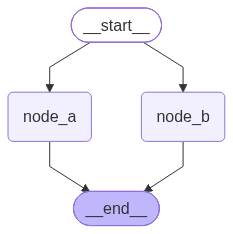

{
    '__interrupt__': [
        Interrupt(value='请输入您的姓名:', id='187c1eff4906ff5af2306cc207eb1380'),
        Interrupt(value='请输入您的年龄:', id='857c8d6f772ef04d9df8c002f2adc368')
    ]
}

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	__start__ --> node_b;
	node_a --> __end__;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from time import sleep
from typing import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint



#1. 声明状态
class OverAllState(TypedDict):
    username:str
    age:int

#2. 声明节点
def node_a(state:OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名:")
    return {
        "username":username
    }

def node_b(state:OverAllState) -> OverAllState:
    sleep(1)
    age = interrupt("请输入您的年龄:")
    return {
        "age":age
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")
builder.add_edge("node_a",END)
builder.add_edge("node_b",END)

#4. 添加检查点后端
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer = checkpointer)

from IPython.display import display
display(graph)

#5. 执行第一个图 => 触发中断
config = {"configurable":{"thread_id":"123"}}
interrupt_res = graph.invoke({},config=config)
rprint(interrupt_res)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

In [4]:
# 6. 恢复执行
resume_map = {}
for i in interrupt_res['__interrupt__']:
    user_input = input(f"{i.value}:")
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resumed_res = graph.invoke(Command(resume=resume_map),config=config)
rprint(resumed_res)
rprint(resume_map)


{'username': 'xiaoming', 'age': 23}

{'187c1eff4906ff5af2306cc207eb1380': 'xiaoming', '857c8d6f772ef04d9df8c002f2adc368': 23}